<a href="https://colab.research.google.com/github/maibamrakeshsingh/One-Dimensional-Thermal-Diffusion-Equation-with-Physics-Informed-Neural-Networks/blob/main/Python%20Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
from scipy.special import erf

# suppress warnings generated by your code:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn
warnings.filterwarnings('ignore')

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [ ]:
class PINNDiffusion(nn.Module):
    def __init__(self):
        super(PINNDiffusion, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 1)
        )

    def forward(self, x, t):
        inputs = torch.cat([x, t], dim=1)
        return self.net(inputs)

In [ ]:
def pinn_loss(x, t, u):
    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]

    pde_loss = u_t - 0.01 * u_xx

    # Loss for initial condition and boundary condition
    ic_loss = torch.mean((u[t.squeeze() == 0] - (x[t.squeeze() == 0] > 0.5).float())**2)
    bc_loss = torch.mean(u[x.squeeze() == 0]**2) + torch.mean((u[x.squeeze() == 1] - 1)**2)

    return torch.mean(pde_loss**2) + ic_loss + bc_loss

In [ ]:
def train(model, optimizer, epochs):
    saved_models = {}
    epoch_saved = []
    for epoch in tqdm(range(epochs), desc="Training Progress"):
        optimizer.zero_grad()

        x = torch.linspace(0, 1, 100, requires_grad=True).unsqueeze(1).to(device)
        t = torch.linspace(0, 1, 100, requires_grad=True).unsqueeze(1).to(device)
        x, t = torch.meshgrid(x.squeeze(), t.squeeze())
        x = x.reshape(-1, 1)
        t = t.reshape(-1, 1)

        u = model(x, t)
        loss = pinn_loss(x, t, u)

        loss.backward()
        optimizer.step()

         # Save the mode
        saved_models[epoch+1] = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        epoch_saved.append(epoch + 1)

    return model, epoch_saved, saved_models

In [ ]:
model = PINNDiffusion().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# Train the model
model, epoch_saved, saved_models = train(model, optimizer, epochs=1500)

Training Progress: 100%|██████████| 1500/1500 [04:02<00:00,  6.18it/s]


In [ ]:
def plot_all_solutions(model):
    model.eval()
    with torch.no_grad():
        x = torch.linspace(0, 1, 100).unsqueeze(1).to(device)
        t_values = [0.25, 0.5, 0.75, 1.0]

        # Reduced figure size
        plt.figure(figsize=(6, 4))  # Reduced from (7, 5)

        # Plot initial condition
        plt.plot(x.cpu().numpy(), np.heaviside(x.cpu().numpy() - 0.5, 0.5), 'k--',
                label='Initial', linewidth=1.5)

        # Plot PINN solutions
        for t in t_values:
            t_tensor = torch.full_like(x, t).to(device)
            u = model(x, t_tensor).cpu().numpy()
            plt.plot(x.cpu().numpy(), u, label=f'PINN t={t:.2f}', linewidth=1.5)

        # Plot theoretical solutions
        D = 0.01  # Diffusion coefficient
        x_np = x.cpu().numpy()
        for t in t_values:
            u_theoretical = 0.5 * (1 + erf((x_np - 0.5) / (2 * np.sqrt(D * t))))
            plt.plot(x_np, u_theoretical, '--', label=f'Exact t={t:.2f}', linewidth=1, alpha=0.7)

        plt.title('PINN vs Exact Solutions', fontsize=12)
        plt.xlabel('x', fontsize=11)
        plt.ylabel('u(x,t)', fontsize=11)
        plt.legend(fontsize=9, loc='best', frameon=False)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()  # Adjust layout to fit everything
        plt.show()


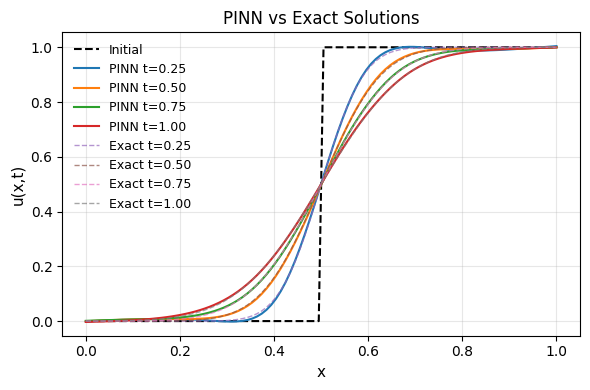

In [ ]:
plot_all_solutions(model)

In [ ]:
def plot_epoch_comparison(epoch_saved, saved_models, device):
    fig, ax = plt.subplots(figsize=(7, 5), dpi=100)
    x = torch.linspace(0, 1, 100).unsqueeze(1).to(device)
    t = torch.full_like(x, 1.0).to(device)

    # Theoretical solution at t=1
    D = 0.01
    x_np = x.cpu().numpy()
    u_theoretical = 0.5 * (1 + erf((x_np - 0.5) / (2 * np.sqrt(D))))

    ax.plot(x_np, u_theoretical, 'k--', label='Theoretical t=1.0')
    line, = ax.plot([], [], 'r-', label='PINN Solution')

    ax.set_title('PINN Solutions at t=1.0 for Different Epochs')
    ax.set_xlabel('x')
    ax.set_ylabel('u(x,1)')
    ax.legend()
    ax.grid(True)

    def init():
        line.set_data([], [])
        return line,

    def update(epoch):
        temp_model = PINNDiffusion().to(device)
        temp_model.load_state_dict(saved_models[epoch])
        temp_model.eval()
        with torch.no_grad():
            u = temp_model(x, t).cpu().numpy()
        line.set_data(x_np, u)
        ax.set_title(f'PINN Solution at t=1.0 for Epoch {epoch}')
        return line,

    ani = animation.FuncAnimation(fig, update, frames=epoch_saved, init_func=init, blit=True, interval=500)

    plt.close(fig)  # Prevents static plot from showing up in notebooks

    return ani

In [ ]:
epoch_show = my_list = [1] + list(range(10, 651, 10)) + list(range(650, 1501, 50))
anim = plot_epoch_comparison(epoch_show, saved_models, device)

In [ ]:
# Usage example
from IPython.display import HTML
HTML(anim.to_jshtml())